In [1]:
from datasets import load_dataset

ds = load_dataset("docling-project/FinTabNet_OTSL")

sample = ds["train"][0]
print(sample.keys())
print(sample["html"][:20])
print(sample["cells"][0])
print(sample["otsl"][:20])

/media/drive-2t/miniconda3/envs/test_hoangnv83/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


dict_keys(['filename', 'split', 'imgid', 'dataset', 'cells', 'otsl', 'html', 'html_restored', 'cols', 'rows', 'html_len', 'otsl_len', 'image'])
['<tr>', '<td>', '</td>', '<td>', '</td>', '</tr>', '<tr>', '<td>', '</td>', '<td>', '</td>', '</tr>', '<tr>', '<td>', '</td>', '<td>', '</td>', '</tr>', '<tr>', '<td>']
[{'tokens': ['L', 'o', 'c', 'a', 't', 'i', 'o', 'n', ' ', 'C', 'o', 'u', 'n', 't', 'r', 'y', ' ', 'o', 'r', ' ', 'S', 't', 'a', 't', 'e'], 'bbox': [-1, 1, 88, 9, 2]}, {'tokens': ['S', 'q', 'u', 'a', 'r', 'e', ' ', 'F', 'e', 'e', 't', ' ', '(', 'i', 'n', ' ', 't', 'h', 'o', 'u', 's', 'a', 'n', 'd', 's', ')'], 'bbox': [255, 1, 337, 9, 2]}, {'tokens': ['C', 'o', 'n', 'n', 'e', 'c', 't', 'i', 'c', 'u', 't'], 'bbox': [1, 16, 42, 24, 2]}, {'tokens': ['1', ',', '0', '9', '8'], 'bbox': [257, 16, 276, 24, 2]}, {'tokens': ['C', 'h', 'i', 'n', 'a'], 'bbox': [1, 29, 20, 37, 2]}, {'tokens': ['9', '8', '5'], 'bbox': [257, 29, 270, 37, 2]}, {'tokens': ['M', 'i', 'n', 'n', 'e', 's', 'o', 't', 

MDT.2018.page_32.pdf_1.png: drew 28 bboxes on 338x184 image


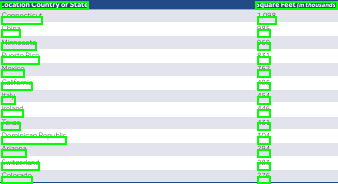

MDT.2018.page_34.pdf_2.png: drew 28 bboxes on 507x52 image


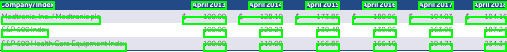

MDT.2018.page_36.pdf_3.png: drew 218 bboxes on 508x487 image


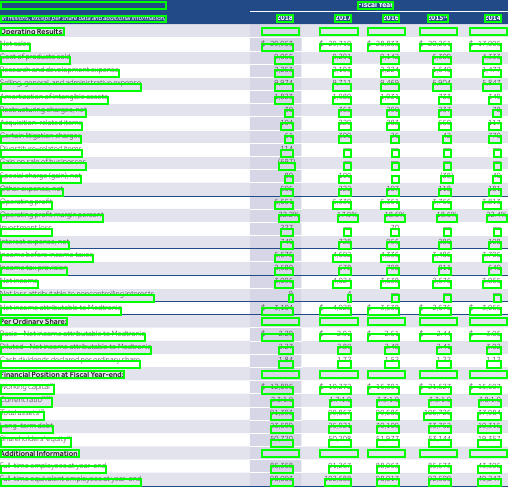

MDT.2018.page_41.pdf_4.png: drew 64 bboxes on 508x105 image


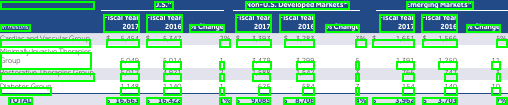

MDT.2018.page_48.pdf_5.png: drew 18 bboxes on 508x63 image


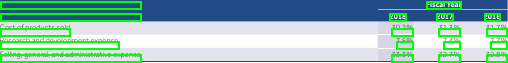

MDT.2018.page_49.pdf_6.png: drew 46 bboxes on 506x157 image


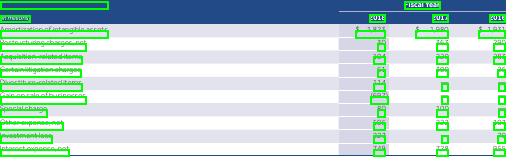

In [2]:
from IPython.display import display
from PIL import ImageDraw


def iter_fintabnet_cells(cells):
    # Dataset nay doi luc boc cells them 1 lop list.
    for item in cells:
        if isinstance(item, dict):
            yield item
        elif isinstance(item, (list, tuple)):
            for sub_item in item:
                if isinstance(sub_item, dict):
                    yield sub_item


def draw_fintabnet_bboxes(sample, show_text=False, color="lime", width=2):
    """Ve bbox dung tren pixel goc cua anh, khong qua truc matplotlib."""
    image = sample["image"].convert("RGB")
    draw = ImageDraw.Draw(image)
    image_w, image_h = image.size

    n_boxes = 0
    for cell in iter_fintabnet_cells(sample["cells"]):
        bbox = cell.get("bbox")
        if not bbox or len(bbox) < 4:
            continue

        # FinTabNet_OTSL bbox co dang [x1, y1, x2, y2, ...]. So thu 5 khong phai toa do.
        x1, y1, x2, y2 = [int(round(v)) for v in bbox[:4]]
        x1 = max(0, min(image_w - 1, x1))
        y1 = max(0, min(image_h - 1, y1))
        x2 = max(0, min(image_w - 1, x2))
        y2 = max(0, min(image_h - 1, y2))

        if x2 <= x1 or y2 <= y1:
            continue

        draw.rectangle([x1, y1, x2, y2], outline=color, width=width)
        n_boxes += 1

        if show_text:
            text = "".join(cell.get("tokens", []))[:30]
            draw.text((x1, max(0, y1 - 10)), text, fill="red")

    print(f"{sample.get('filename', '')}: drew {n_boxes} bboxes on {image_w}x{image_h} image")
    display(image)
    return image


# Bbox trong field cells la bbox vung text/OCR, khong phai full cell/table grid.
for idx in range(6):
    draw_fintabnet_bboxes(ds["train"][idx])


In [3]:
from collections import Counter, defaultdict
import re, math
import pandas as pd
from datasets import load_dataset

ds = load_dataset("docling-project/FinTabNet_OTSL")

MAX_ROWS_PER_SPLIT = None   # set 2000 để test nhanh
CHECK_IMAGES = False        # True sẽ check bbox ngoài ảnh

SPAN_RE = re.compile(r'(rowspan|colspan)="(\d+)"')

def iter_fintabnet_cells(cells):
    # FinTabNet_OTSL đôi lúc bọc cells thêm 1 lớp list
    for item in cells:
        if isinstance(item, dict):
            yield item
        elif isinstance(item, (list, tuple)):
            for sub_item in item:
                if isinstance(sub_item, dict):
                    yield sub_item

def cell_text(tokens):
    return "".join(
        t for t in tokens
        if not (isinstance(t, str) and t.startswith("<") and t.endswith(">"))
    ).strip()

def parse_structure(tokens):
    rows, spans = [], []
    future = defaultdict(set)
    row, col, in_row = -1, 0, False
    i = 0

    while i < len(tokens):
        t = tokens[i]

        if t == "<tr>":
            row += 1
            col = 0
            in_row = True
            rows.append(set(future.pop(row, set())))
            i += 1
            continue

        if t == "</tr>":
            in_row = False
            i += 1
            continue

        is_cell = (
            in_row and isinstance(t, str) and (
                t in ("<td>", "<th>", "<td", "<th")
                or t.startswith("<td ")
                or t.startswith("<th ")
            )
        )

        if is_cell:
            attrs = t
            j = i + 1

            if t in ("<td", "<th"):
                while j < len(tokens) and tokens[j] != ">":
                    attrs += tokens[j]
                    j += 1
                i = j

            rowspan, colspan = 1, 1
            for key, value in SPAN_RE.findall(attrs):
                if key == "rowspan":
                    rowspan = int(value)
                elif key == "colspan":
                    colspan = int(value)

            while col in rows[row]:
                col += 1

            for c in range(col, col + colspan):
                rows[row].add(c)

            if rowspan > 1:
                for r in range(row + 1, row + rowspan):
                    for c in range(col, col + colspan):
                        future[r].add(c)

            spans.append((rowspan, colspan))
            col += colspan

        i += 1

    n_rows = len(rows)
    n_cols = max((max(r) + 1 for r in rows if r), default=0)
    return n_rows, n_cols, spans


def difficulty_reasons(row):
    reasons = []
    if row["grid_slots"] >= 120:
        reasons.append("large_grid")
    if row["rows"] >= 20:
        reasons.append("many_rows")
    if row["columns"] >= 10:
        reasons.append("many_columns")
    if row["merged_cells"] > 0:
        reasons.append("merged_cells")
    if row["span_extra_slots"] > 0:
        reasons.append("span_extra_slots")
    if row["empty_cell_rate"] >= 0.25:
        reasons.append("sparse_table")
    if not row["cell_alignment_ok"]:
        reasons.append("structure_alignment_issue")
    if row["missing_bbox_nonempty"] > 0:
        reasons.append("missing_bbox_nonempty")
    if row["invalid_bbox"] > 0:
        reasons.append("invalid_bbox")
    if row["outside_bbox"] > 0:
        reasons.append("outside_bbox")
    return "|".join(reasons)


def difficulty_score(row):
    # Custom EDA heuristic, not an official PubTabNet/FinTabNet metric.
    size_score = math.log1p(max(row["grid_slots"], 0))
    span_score = (
        2.0 * math.log1p(max(row["merged_cells"], 0))
        + 0.5 * math.log1p(max(row["span_extra_slots"], 0))
        + 0.5 * max(row["max_rowspan"] - 1, 0)
        + 0.5 * max(row["max_colspan"] - 1, 0)
    )
    sparsity_score = 2.0 * row["empty_cell_rate"]
    shape_score = (
        1.0 * int(row["rows"] >= 20)
        + 1.0 * int(row["columns"] >= 10)
        + 1.0 * int(row["grid_slots"] >= 120)
    )
    quality_score = (
        1.5 * int(not row["cell_alignment_ok"])
        + 1.0 * int(row["missing_bbox_nonempty"] > 0)
        + 1.0 * int(row["invalid_bbox"] > 0)
        + 1.0 * int(row["outside_bbox"] > 0)
    )
    return size_score + span_score + sparsity_score + shape_score + quality_score


def add_difficulty_columns(df):
    df = df.copy()
    df["difficulty_reasons"] = df.apply(difficulty_reasons, axis=1)
    df["has_difficulty_reason"] = df["difficulty_reasons"].ne("")
    df["difficulty_score"] = df.apply(difficulty_score, axis=1)
    df["difficulty_level"] = "medium"

    for split, idx in df.groupby("split").groups.items():
        scores = df.loc[idx, "difficulty_score"]
        low = scores.quantile(0.33)
        high = scores.quantile(0.67)

        levels = pd.Series("medium", index=idx, dtype="object")
        if low < high:
            levels.loc[scores <= low] = "easy"
            levels.loc[scores >= high] = "hard"
        df.loc[idx, "difficulty_level"] = levels

    return df

records = []
span_counter = Counter()

for split in ds.keys():
    dataset = ds[split]

    for idx, d in enumerate(dataset, start=1):
        cells = list(iter_fintabnet_cells(d["cells"]))

        tokens = d.get("html_restored") or d.get("html") or []
        parsed_rows, parsed_cols, spans = parse_structure(tokens)

        # FinTabNet_OTSL có sẵn rows/cols, ưu tiên dùng field này
        rows = d.get("rows", parsed_rows)
        cols = d.get("cols", parsed_cols)

        empty_cells = sum(1 for c in cells if not cell_text(c.get("tokens", [])))
        nonempty_cells = len(cells) - empty_cells
        merged_cells = sum(1 for rs, cs in spans if rs > 1 or cs > 1)
        span_extra_slots = sum(rs * cs - 1 for rs, cs in spans)

        missing_bbox_nonempty = 0
        invalid_bbox = 0
        outside_bbox = 0

        shape = None
        if CHECK_IMAGES:
            shape = d["image"].size  # (w, h)

        for c in cells:
            txt = cell_text(c.get("tokens", []))
            bbox = c.get("bbox")

            if txt and bbox is None:
                missing_bbox_nonempty += 1

            if bbox is not None:
                # FinTabNet bbox có thể dài 5 phần tử, chỉ lấy 4 tọa độ đầu
                ok = (
                    isinstance(bbox, list)
                    and len(bbox) >= 4
                    and bbox[2] > bbox[0]
                    and bbox[3] > bbox[1]
                )

                if not ok:
                    invalid_bbox += 1
                elif shape is not None:
                    w, h = shape
                    x1, y1, x2, y2 = bbox[:4]
                    if x1 < 0 or y1 < 0 or x2 > w or y2 > h:
                        outside_bbox += 1

        for rs, cs in spans:
            span_counter[(split, rs, cs)] += 1

        records.append({
            "filename": d["filename"],
            "split": split,
            "rows": rows,
            "columns": cols,
            "grid_slots": rows * cols,
            "cells": len(cells),
            "nonempty_cells": nonempty_cells,
            "empty_cells": empty_cells,
            "empty_cell_rate": empty_cells / max(len(cells), 1),
            "merged_cells": merged_cells,
            "merged_cell_rate": merged_cells / max(len(cells), 1),
            "span_extra_slots": span_extra_slots,
            "max_rowspan": max((rs for rs, _ in spans), default=1),
            "max_colspan": max((cs for _, cs in spans), default=1),
            "cell_alignment_ok": len(cells) == len(spans),
            "missing_bbox_nonempty": missing_bbox_nonempty,
            "invalid_bbox": invalid_bbox,
            "outside_bbox": outside_bbox,
        })

        if idx % 10000 == 0:
            print(f"{split}: processed {idx:,}")

        if MAX_ROWS_PER_SPLIT and idx >= MAX_ROWS_PER_SPLIT:
            break

df = pd.DataFrame(records)
df = add_difficulty_columns(df)

summary = df.groupby("split").agg(
    tables=("filename", "count"),
    rows_mean=("rows", "mean"),
    rows_p50=("rows", "median"),
    rows_max=("rows", "max"),
    columns_mean=("columns", "mean"),
    columns_p50=("columns", "median"),
    columns_max=("columns", "max"),
    cells_mean=("cells", "mean"),
    cells_max=("cells", "max"),
    empty_cells_sum=("empty_cells", "sum"),
    empty_cell_rate_mean=("empty_cell_rate", "mean"),
    merged_cells_sum=("merged_cells", "sum"),
    merged_cell_rate_mean=("merged_cell_rate", "mean"),
    span_extra_slots_sum=("span_extra_slots", "sum"),
    bad_structure_cells=("cell_alignment_ok", lambda s: (~s).sum()),
    missing_bbox_nonempty_sum=("missing_bbox_nonempty", "sum"),
    invalid_bbox_sum=("invalid_bbox", "sum"),
    outside_bbox_sum=("outside_bbox", "sum"),
    difficult_tables=("has_difficulty_reason", "sum"),
    difficulty_score_mean=("difficulty_score", "mean"),
    difficulty_score_p95=("difficulty_score", lambda s: s.quantile(0.95)),
    difficulty_score_max=("difficulty_score", "max"),
).reset_index()

size_distribution = (
    df.groupby("split")[["rows", "columns", "cells", "grid_slots", "empty_cells", "merged_cells"]]
      .describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
)

span_patterns = pd.DataFrame(
    [
        {"split": split, "rowspan": rs, "colspan": cs, "count": count}
        for (split, rs, cs), count in span_counter.items()
    ]
).sort_values(["split", "count"], ascending=[True, False])

span_summary = (
    span_patterns
    .assign(
        rowspan_x_count=lambda d: d["rowspan"] * d["count"],
        colspan_x_count=lambda d: d["colspan"] * d["count"],
    )
    .groupby("split")
    .agg(
        span_cells=("count", "sum"),
        rowspan_min=("rowspan", "min"),
        rowspan_max=("rowspan", "max"),
        rowspan_mean_weighted=("rowspan_x_count", "sum"),
        colspan_min=("colspan", "min"),
        colspan_max=("colspan", "max"),
        colspan_mean_weighted=("colspan_x_count", "sum"),
    )
    .reset_index()
)

span_summary["rowspan_mean_weighted"] = (
    span_summary["rowspan_mean_weighted"] / span_summary["span_cells"]
)
span_summary["colspan_mean_weighted"] = (
    span_summary["colspan_mean_weighted"] / span_summary["span_cells"]
)

image_counts = pd.DataFrame({
    "split": list(ds.keys()),
    "image_files": [len(ds[s]) for s in ds.keys()],
})


difficulty_distribution = (
    pd.crosstab(df["split"], df["difficulty_level"], normalize="index")
    .round(3)
    .reset_index()
)

top_difficult_tables = (
    df.sort_values("difficulty_score", ascending=False)
    [[
        "split",
        "filename",
        "rows",
        "columns",
        "grid_slots",
        "empty_cells",
        "empty_cell_rate",
        "merged_cells",
        "span_extra_slots",
        "max_rowspan",
        "max_colspan",
        "difficulty_score",
        "difficulty_level",
        "difficulty_reasons",
    ]]
    .head(30)
)

display(summary)
display(size_distribution)
display(span_patterns.groupby("split").head(20))
display(span_summary)
display(image_counts)

display(difficulty_distribution)
display(top_difficult_tables)

train: processed 10,000
train: processed 20,000
train: processed 30,000
train: processed 40,000
train: processed 50,000
train: processed 60,000
train: processed 70,000
train: processed 80,000
test: processed 10,000
val: processed 10,000


,split,tables,rows_mean,rows_p50,rows_max,columns_mean,columns_p50,columns_max,cells_mean,cells_max,...,merged_cell_rate_mean,span_extra_slots_sum,bad_structure_cells,missing_bbox_nonempty_sum,invalid_bbox_sum,outside_bbox_sum,difficult_tables,difficulty_score_mean,difficulty_score_p95,difficulty_score_max
0,test,10397,11.345100,8.0,69,4.151582,4.0,16,46.192940,597,...,0.024540,18573,0,0,16,0,6132,5.889202,11.201816,20.473738
1,train,88441,12.069594,9.0,83,4.365113,4.0,19,52.842471,680,...,0.022719,175724,0,0,2912,0,52113,6.109383,11.881700,22.107372
2,val,10505,10.958972,8.0,66,4.238934,4.0,18,45.510138,506,...,0.020028,15280,0,0,1,0,5602,5.596656,10.568849,18.353391


rows                                                              \
         count       mean       std  min  25%  50%   75%   90%   95%   99%   
split                                                                        
test   10397.0  11.345100  9.282875  2.0  6.0  8.0  13.0  22.0  32.0  49.0   
train  88441.0  12.069594  9.858092  2.0  6.0  9.0  14.0  25.0  34.0  50.0   
val    10505.0  10.958972  8.821543  2.0  6.0  8.0  13.0  21.0  30.0  47.0   

       ... merged_cells                                                     
       ...         mean       std  min  25%  50%  75%  90%  95%  99%   max  
split  ...                                                                  
test   ...     0.881408  1.211271  0.0  0.0  1.0  2.0  2.0  3.0  5.0  33.0  
train  ...     0.964089  1.570210  0.0  0.0  1.0  2.0  2.0  3.0  6.0  62.0  
val    ...     0.731747  1.034720  0.0  0.0  0.0  1.0  2.0  3.0  4.0  12.0  

[3 rows x 66 columns]

,split,rowspan,colspan,count
22,test,1,1,471104
23,test,1,3,3689
25,test,1,2,3542
26,test,1,4,819
24,test,1,5,686
27,test,1,6,243
28,test,1,7,109
29,test,1,8,43
30,test,1,9,22
31,test,1,10,6


,split,span_cells,rowspan_min,rowspan_max,rowspan_mean_weighted,colspan_min,colspan_max,colspan_mean_weighted
0,test,480268,1,1,1.000000,1,12,1.038672
1,train,4673441,1,10,1.000011,1,16,1.037589
2,val,478084,1,1,1.000000,1,12,1.031961


,split,image_files
0,train,88441
1,test,10397
2,val,10505


difficulty_level,split,easy,hard,medium
0,test,0.330,0.330,0.340
1,train,0.330,0.330,0.340
2,val,0.335,0.331,0.335


,split,filename,rows,columns,grid_slots,empty_cells,empty_cell_rate,merged_cells,span_extra_slots,max_rowspan,max_colspan,difficulty_score,difficulty_level,difficulty_reasons
61627,train,JPM.2015.page_107.pdf_103662.png,21,14,294,84,0.315789,9,28,1,14,22.107372,hard,large_grid|many_rows|many_columns|merged_cells...
61362,train,JPM.2014.page_97.pdf_103390.png,20,14,280,72,0.285714,9,28,1,14,21.998601,hard,large_grid|many_rows|many_columns|merged_cells...
136,train,ZION.2014.page_69.pdf_580.png,40,13,520,78,0.165254,8,48,1,13,21.926618,hard,large_grid|many_rows|many_columns|merged_cells...
29362,train,GIS.2018.page_87.pdf_50460.png,9,17,153,23,0.201754,11,39,1,16,21.754714,hard,large_grid|many_columns|merged_cells|span_extr...
29609,train,GIS.2019.page_81.pdf_50793.png,9,17,153,23,0.201754,11,39,1,16,21.754714,hard,large_grid|many_columns|merged_cells|span_extr...
31592,train,HIG.2016.page_202.pdf_52968.png,17,11,187,18,0.134328,35,53,1,11,21.666629,hard,large_grid|many_columns|merged_cells|span_extr...
69113,train,GL.2014.page_118.pdf_115944.png,30,11,330,63,0.218750,18,42,1,10,21.509096,hard,large_grid|many_rows|many_columns|merged_cells...
16729,train,RE.2012.page_19.pdf_29262.png,53,11,583,190,0.346715,9,35,1,11,21.460261,hard,large_grid|many_rows|many_columns|merged_cells...
16816,train,RE.2014.page_28.pdf_29359.png,19,13,247,83,0.378995,18,28,1,12,21.343945,hard,large_grid|many_columns|merged_cells|span_extr...
30088,train,MET.2014.page_224.pdf_51297.png,20,13,260,29,0.130045,11,37,1,12,21.113216,hard,large_grid|many_rows|many_columns|merged_cells...


## Selected-feature plots and hard 200 samples

Vẽ đúng 7 thông số đã chốt và trích xuất 200 samples khó cho `fintabnet`. Manifest được lưu trong folder `fintabnet_samples`.


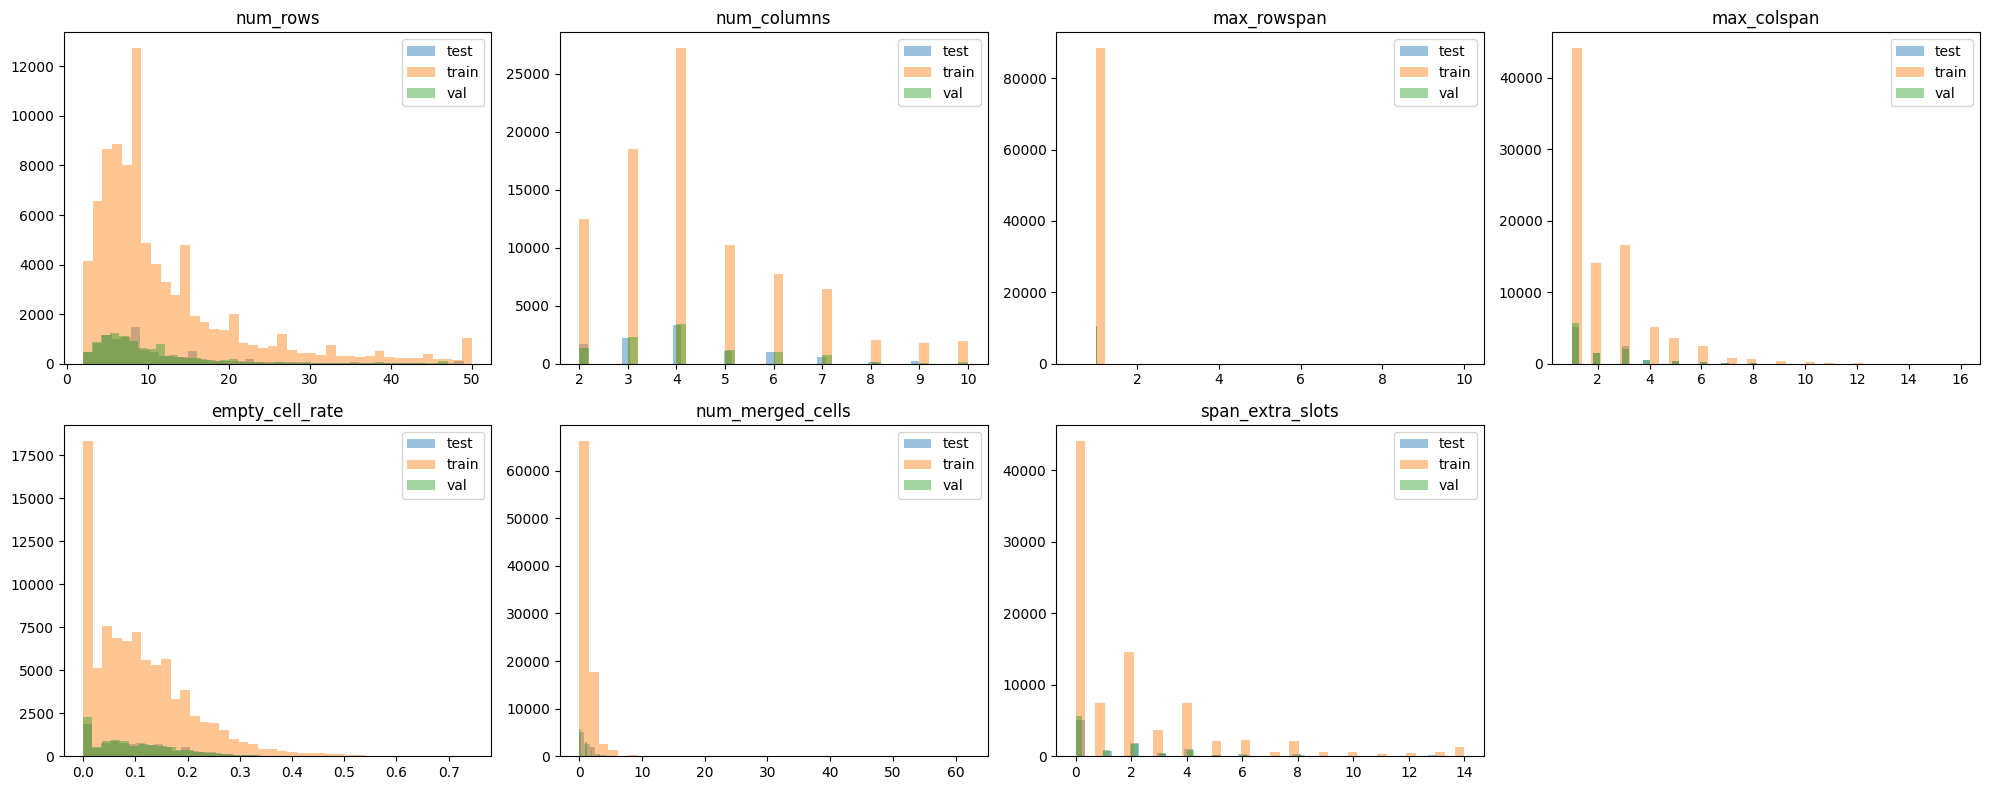

In [4]:
# Visualize only the selected 7 EDA features.
import matplotlib.pyplot as plt

plot_df = df.copy()
plot_df["num_rows"] = plot_df["rows"]
plot_df["num_columns"] = plot_df["columns"]
plot_df["num_merged_cells"] = plot_df["merged_cells"]

plot_cols = [
    "num_rows",
    "num_columns",
    "max_rowspan",
    "max_colspan",
    "empty_cell_rate",
    "num_merged_cells",
    "span_extra_slots",
]

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.ravel()

for ax, col in zip(axes, plot_cols):
    for split in sorted(plot_df["split"].unique()):
        values = plot_df.loc[plot_df["split"] == split, col].dropna()
        if col in {"num_rows", "num_columns", "span_extra_slots"} and len(values) > 0:
            values = values.clip(upper=values.quantile(0.99))
        ax.hist(values, bins=40, alpha=0.45, label=split)
    ax.set_title(col)
    ax.legend()

axes[-1].axis("off")
plt.tight_layout()
plt.show()


In [6]:
# Extract 200 hard samples using the same 7 selected features.
from pathlib import Path
import math

DATASET_NAME = "fintabnet"
SAMPLE_OUT_DIR = Path("/media/drive-2t/hoangnv83/code/3u/graph/fintabnet_samples")
SAMPLE_OUT_DIR.mkdir(parents=True, exist_ok=True)

sample_df = df.copy()
sample_df["num_rows"] = sample_df["rows"]
sample_df["num_columns"] = sample_df["columns"]
sample_df["num_merged_cells"] = sample_df["merged_cells"]
sample_df["empty_cell_rate"] = sample_df["empty_cell_rate"].fillna(0.0)
sample_df["max_rowspan"] = sample_df["max_rowspan"].fillna(1).astype(int)
sample_df["max_colspan"] = sample_df["max_colspan"].fillna(1).astype(int)
sample_df["num_merged_cells"] = sample_df["num_merged_cells"].fillna(0).astype(int)
sample_df["span_extra_slots"] = sample_df["span_extra_slots"].fillna(0).astype(int)

# Stable sample/source ids for manifest export.
if "source_id" not in sample_df.columns:
    sample_df["source_id"] = sample_df["filename"]
sample_df["sample_id"] = sample_df["filename"]


def level_num_rows(num_rows):
    if num_rows <= 5:
        return 0
    if num_rows <= 15:
        return 1
    if num_rows <= 30:
        return 2
    return 3


def level_num_columns(num_columns):
    if num_columns <= 4:
        return 0
    if num_columns <= 8:
        return 1
    if num_columns <= 12:
        return 2
    return 3


def level_rowspan(max_rowspan):
    if max_rowspan <= 1:
        return 0
    if max_rowspan == 2:
        return 1
    if max_rowspan <= 4:
        return 2
    return 3


def level_colspan(max_colspan):
    if max_colspan <= 1:
        return 0
    if max_colspan == 2:
        return 1
    if max_colspan <= 5:
        return 2
    return 3


def level_empty_cell_rate(empty_cell_rate):
    if empty_cell_rate <= 0:
        return 0
    if empty_cell_rate <= 0.10:
        return 1
    if empty_cell_rate <= 0.30:
        return 2
    return 3


def level_num_merged_cells(num_merged_cells):
    if num_merged_cells <= 0:
        return 0
    if num_merged_cells <= 2:
        return 1
    if num_merged_cells <= 5:
        return 2
    return 3


def level_span_extra_slots(span_extra_slots):
    if span_extra_slots <= 0:
        return 0
    if span_extra_slots <= 3:
        return 1
    if span_extra_slots <= 9:
        return 2
    return 3


def difficulty_flags(row):
    flags = []
    if level_num_rows(row["num_rows"]) >= 2:
        flags.append("many_rows")
    if level_num_columns(row["num_columns"]) >= 2:
        flags.append("many_columns")
    if level_rowspan(row["max_rowspan"]) >= 2:
        flags.append("large_rowspan")
    if level_colspan(row["max_colspan"]) >= 2:
        flags.append("large_colspan")
    if level_empty_cell_rate(row["empty_cell_rate"]) >= 2:
        flags.append("many_empty_cells")
    if level_num_merged_cells(row["num_merged_cells"]) >= 2:
        flags.append("many_merged_cells")
    if level_span_extra_slots(row["span_extra_slots"]) >= 2:
        flags.append("complex_span")
    return flags


def difficulty_score(row):
    return (
        1.0 * level_num_rows(row["num_rows"])
        + 1.0 * level_num_columns(row["num_columns"])
        + 1.5 * level_rowspan(row["max_rowspan"])
        + 1.5 * level_colspan(row["max_colspan"])
        + 1.0 * level_empty_cell_rate(row["empty_cell_rate"])
        + 1.5 * level_num_merged_cells(row["num_merged_cells"])
        + 1.5 * level_span_extra_slots(row["span_extra_slots"])
    )


def difficulty_level(score):
    if score < 6:
        return "easy"
    if score < 12:
        return "medium"
    if score < 18:
        return "hard"
    return "very_hard"


sample_df["row_level"] = sample_df["num_rows"].map(level_num_rows)
sample_df["column_level"] = sample_df["num_columns"].map(level_num_columns)
sample_df["rowspan_level"] = sample_df["max_rowspan"].map(level_rowspan)
sample_df["colspan_level"] = sample_df["max_colspan"].map(level_colspan)
sample_df["empty_level"] = sample_df["empty_cell_rate"].map(level_empty_cell_rate)
sample_df["merged_level"] = sample_df["num_merged_cells"].map(level_num_merged_cells)
sample_df["span_extra_level"] = sample_df["span_extra_slots"].map(level_span_extra_slots)
sample_df["difficulty_score"] = sample_df.apply(difficulty_score, axis=1)
sample_df["difficulty_level"] = sample_df["difficulty_score"].map(difficulty_level)
sample_df["difficulty_flags"] = sample_df.apply(lambda row: "|".join(difficulty_flags(row)), axis=1)
sample_df["num_difficulty_flags"] = sample_df["difficulty_flags"].map(lambda x: 0 if not x else len(x.split("|")))


def resolve_split_quotas(existing_splits):
    existing_splits = set(existing_splits)
    quotas = {"train": 140, "val": 40, "test": 20}
    if "val" not in existing_splits and "validation" in existing_splits:
        quotas["validation"] = quotas.pop("val")
    return {split: quota for split, quota in quotas.items() if split in existing_splits}


DIVERSITY_FLAGS = [
    "many_rows",
    "many_columns",
    "large_rowspan",
    "large_colspan",
    "many_empty_cells",
    "many_merged_cells",
    "complex_span",
]


def select_hard_subset_for_split(df, split, quota):
    part = df[df["split"] == split].copy()
    part = part.sort_values(
        ["difficulty_score", "num_difficulty_flags", "num_rows", "num_columns", "num_merged_cells", "span_extra_slots"],
        ascending=[False, False, False, False, False, False],
    )

    top_quota = int(round(quota * 0.70))
    selected = part.head(top_quota).copy()
    selected["selection_reason"] = "top_difficulty_score"
    selected_ids = set(selected["sample_id"])

    remaining_quota = quota - len(selected)
    per_flag = max(1, math.ceil(remaining_quota / len(DIVERSITY_FLAGS)))
    diversity_rows = []

    for flag in DIVERSITY_FLAGS:
        candidates = part[
            part["difficulty_flags"].str.contains(flag, regex=False, na=False)
            & ~part["sample_id"].isin(selected_ids)
        ].head(per_flag).copy()
        candidates["selection_reason"] = flag
        diversity_rows.append(candidates)
        selected_ids.update(candidates["sample_id"])

    if diversity_rows:
        selected = pd.concat([selected] + diversity_rows, ignore_index=True)
        selected = selected.drop_duplicates("sample_id", keep="first")

    if len(selected) < quota:
        fill = part[~part["sample_id"].isin(set(selected["sample_id"]))].head(quota - len(selected)).copy()
        fill["selection_reason"] = "quota_fill_top_score"
        selected = pd.concat([selected, fill], ignore_index=True)

    return selected.head(quota)


split_quotas = resolve_split_quotas(sample_df["split"].unique())
hard_subset_200 = pd.concat(
    [select_hard_subset_for_split(sample_df, split, quota) for split, quota in split_quotas.items()],
    ignore_index=True,
)

manifest_cols = [
    "split",
    "sample_id",
    "source_id",
    "filename",
    "num_rows",
    "num_columns",
    "grid_slots",
    "max_rowspan",
    "max_colspan",
    "empty_cell_rate",
    "num_merged_cells",
    "span_extra_slots",
    "row_level",
    "column_level",
    "rowspan_level",
    "colspan_level",
    "empty_level",
    "merged_level",
    "span_extra_level",
    "difficulty_score",
    "difficulty_level",
    "difficulty_flags",
    "selection_reason",
]

hard_subset_200[manifest_cols].to_csv(SAMPLE_OUT_DIR / f"{DATASET_NAME}_hard_200_manifest.csv", index=False)
hard_subset_200[manifest_cols].to_json(
    SAMPLE_OUT_DIR / f"{DATASET_NAME}_hard_200_manifest.jsonl",
    orient="records",
    lines=True,
    force_ascii=False,
)

print("selected:", len(hard_subset_200))
display(hard_subset_200["split"].value_counts())
display(hard_subset_200["selection_reason"].value_counts())
print("Saved:", SAMPLE_OUT_DIR / f"{DATASET_NAME}_hard_200_manifest.csv")
print("Saved:", SAMPLE_OUT_DIR / f"{DATASET_NAME}_hard_200_manifest.jsonl")

hard_subset_200[manifest_cols].head(20)


selected: 200


split
train    140
val       40
test      20
Name: count, dtype: int64

selection_reason
top_difficulty_score    140
many_rows                 9
many_columns              9
large_colspan             9
many_empty_cells          9
many_merged_cells         9
complex_span              9
large_rowspan             6
Name: count, dtype: int64

Saved: /media/drive-2t/hoangnv83/code/3u/graph/fintabnet_samples/fintabnet_hard_200_manifest.csv
Saved: /media/drive-2t/hoangnv83/code/3u/graph/fintabnet_samples/fintabnet_hard_200_manifest.jsonl


,split,sample_id,source_id,filename,num_rows,num_columns,grid_slots,max_rowspan,max_colspan,empty_cell_rate,...,column_level,rowspan_level,colspan_level,empty_level,merged_level,span_extra_level,difficulty_score,difficulty_level,difficulty_flags,selection_reason
0,train,RE.2007.page_19.pdf_29448.png,RE.2007.page_19.pdf_29448.png,RE.2007.page_19.pdf_29448.png,61,11,671,1,10,0.353033,...,2,0,3,3,3,3,21.5,very_hard,many_rows|many_columns|large_colspan|many_empt...,top_difficulty_score
1,train,RE.2012.page_19.pdf_29262.png,RE.2012.page_19.pdf_29262.png,RE.2012.page_19.pdf_29262.png,53,11,583,1,11,0.346715,...,2,0,3,3,3,3,21.5,very_hard,many_rows|many_columns|large_colspan|many_empt...,top_difficulty_score
2,train,HBAN.2016.page_65.pdf_108628.png,HBAN.2016.page_65.pdf_108628.png,HBAN.2016.page_65.pdf_108628.png,48,11,528,1,10,0.428016,...,2,0,3,3,3,3,21.5,very_hard,many_rows|many_columns|large_colspan|many_empt...,top_difficulty_score
3,train,FCX.2012.page_111.pdf_20819.png,FCX.2012.page_111.pdf_20819.png,FCX.2012.page_111.pdf_20819.png,44,11,484,1,10,0.443966,...,2,0,3,3,3,3,21.5,very_hard,many_rows|many_columns|large_colspan|many_empt...,top_difficulty_score
4,train,ZION.2014.page_69.pdf_580.png,ZION.2014.page_69.pdf_580.png,ZION.2014.page_69.pdf_580.png,40,13,520,1,13,0.165254,...,3,0,3,2,3,3,21.5,very_hard,many_rows|many_columns|large_colspan|many_empt...,top_difficulty_score
5,train,RJF.2017.page_81.pdf_98871.png,RJF.2017.page_81.pdf_98871.png,RJF.2017.page_81.pdf_98871.png,40,10,400,1,9,0.356021,...,2,0,3,3,3,3,21.5,very_hard,many_rows|many_columns|large_colspan|many_empt...,top_difficulty_score
6,train,GL.2006.page_104.pdf_116143.png,GL.2006.page_104.pdf_116143.png,GL.2006.page_104.pdf_116143.png,35,9,315,1,9,0.430556,...,2,0,3,3,3,3,21.5,very_hard,many_rows|many_columns|large_colspan|many_empt...,top_difficulty_score
7,train,RJF.2014.page_84.pdf_98697.png,RJF.2014.page_84.pdf_98697.png,RJF.2014.page_84.pdf_98697.png,34,11,374,1,10,0.352770,...,2,0,3,3,3,3,21.5,very_hard,many_rows|many_columns|large_colspan|many_empt...,top_difficulty_score
8,train,GL.2007.page_110.pdf_116019.png,GL.2007.page_110.pdf_116019.png,GL.2007.page_110.pdf_116019.png,34,9,306,1,9,0.410628,...,2,0,3,3,3,3,21.5,very_hard,many_rows|many_columns|large_colspan|many_empt...,top_difficulty_score
9,train,GL.2006.page_105.pdf_116144.png,GL.2006.page_105.pdf_116144.png,GL.2006.page_105.pdf_116144.png,34,9,306,1,9,0.410628,...,2,0,3,3,3,3,21.5,very_hard,many_rows|many_columns|large_colspan|many_empt...,top_difficulty_score
